# Del 2 – Fördjupad analys och pipeline (Hälsostudie)

I denna del fortsätter jag utveckla min analys från del 1 genom att:

- Strukturera om projektet i funktioner, moduler och en klass.

- Utföra linjär algebra i praktiken genom en enkel regressionsmodell.

- Skapa ny utökad analys och visualisering.

- Arbeta med en organiserad och reproducerbar pipeline.

# Importera och konfigurera miljön

Jag börjar med att importera nödvändiga paket samt sätta ett seed för att göra analysen reproducerbar.

In [1]:
import numpy as np
np.random.seed(42)

from src.data_loader import load_health_data
from src.analysis import calculate_bmi, HealthAnalyzer
from src.visualizer import (
    plot_bloodpressure_age,
    plot_bmi_bloodpressure,
    plot_bloodpressure_by_agegroup
)


Ladda datasetet

Datan laddas med en funktion i src/data_loader.py.
Jag använder en relativ sökväg (data/health_study_dataset.csv) så notebooken fungerar oavsett miljö.

## Beräkna BMI

BMI (Body Mass Index) beräknas med formeln:

\[
BMI = \frac{vikt\ (kg)}{(längd\ (m))^2}
\]

Jag använder funktionen `calculate_bmi()` från `analysis.py`.
Den skapar en ny kolumn utan att ändra original-dataframe (via `.copy()`).


In [2]:
df = load_health_data()
df = calculate_bmi(df)
df.head()


,id,age,sex,height,weight,systolic_bp,cholesterol,smoker,disease,BMI
0,1,57,F,168.9,65.8,141.8,4.58,No,0,23.065698
1,2,47,M,180.4,95.9,144.8,5.18,Yes,0,29.467653
2,3,59,F,169.9,82.2,151.7,6.16,No,0,28.476398
3,4,72,M,157.7,93.1,151.0,6.63,No,0,37.435729
4,5,46,M,192.6,104.1,144.1,5.21,No,0,28.063263


## HealthAnalyzer-klassen

Jag använder klassen `HealthAnalyzer` för att kapsla analyslogik.
Den tar in datasetet vid initiering och erbjuder två analyser:

- medelvärde av blodtryck
- enkel linjär regression med hjälp av NumPy och normalekvationen

Detta visar hur objektorienterad programmering kan användas
för att organisera analys av data i större projekt.


In [3]:
analyzer = HealthAnalyzer(df)

mean_bp = analyzer.mean_blood_pressure()

print(mean_bp)


149.178625


### Linjär regression (normalekvationen)

Här undersöker jag hur systoliskt blodtryck påverkas av två variabler:
ålder och vikt.

Jag beräknar regressionskoefficienterna direkt i NumPy med normalekvationen:

\[
\beta = (X^T X)^{-1} X^T y
\]

där:
- X = bias (1), age, weight
- y = systolic_bp
- β = [intercept, age_coef, weight_coef]

Modellen visar hur mycket blodtrycket i genomsnitt ökar per år och per kilo.


In [4]:
beta = analyzer.age_weight_regression()
print(beta)

[109.49908145   0.53892763   0.17765752]


#### Tolkning av regressionsresultatet

- β0 (intercept) representerar basnivån av blodtryck vid age=0 och weight=0 (teoretiskt).
- β1 anger hur blodtrycket förändras per extra år.
- β2 anger hur blodtrycket förändras per extra kilogram vikt.

Dessa koefficienter ska inte tolkas kliniskt, utan som samband i just detta dataset.


## Visualiseringar av sambanden

För att undersöka sambanden visuellt använder jag tre plottar:

1. Blood Pressure vs Age — spridningsdiagram som visar relation över livslängd.
2. Blood Pressure vs BMI — upptäcker eventuell vikt/tryck-korrelation.
3. Medel-blodtryck per åldersgrupp — aggregerad nivåbild av tryck över livsfaser.

Dessa grafer hjälper att förstå de statistiska sambanden på en mer intuitiv nivå.


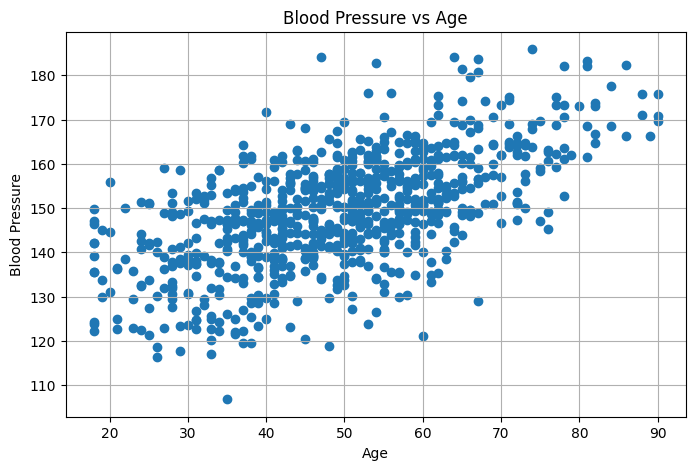

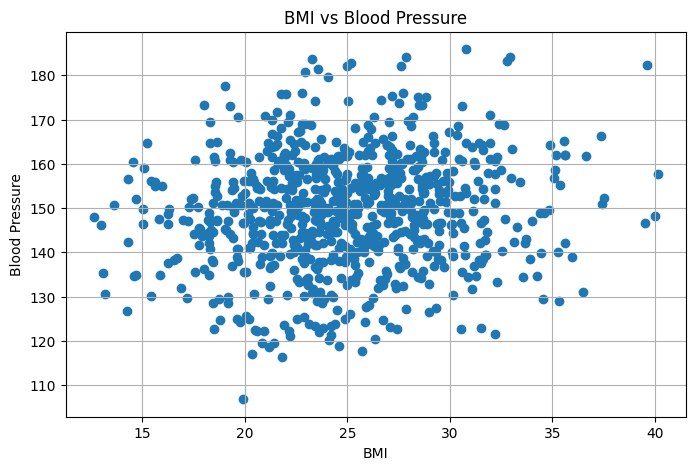

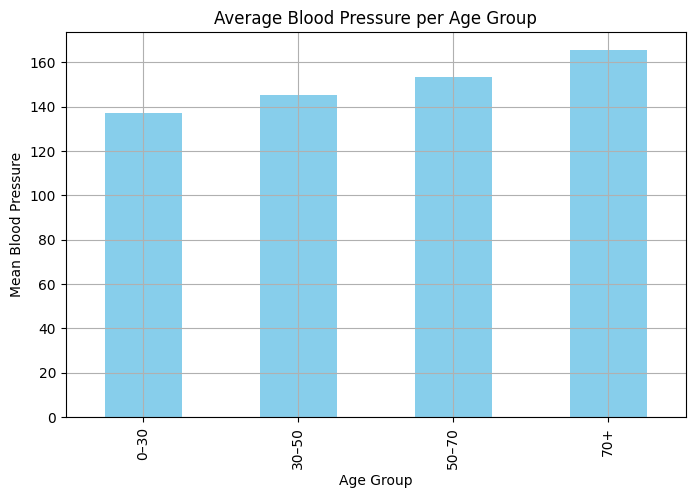

In [5]:
plot_bloodpressure_age(df)
plot_bmi_bloodpressure(df)
plot_bloodpressure_by_agegroup(df)


## Sammanfattning

I denna del har jag:
- Strukturerat koden i moduler (data_loader, analysis, visualizer)
- Skapat en klass (`HealthAnalyzer`)
- Utfört linjär regression med normalekvationen
- Lagt till BMI som feature
- Gjort flera visualiseringar som fördjupar analysen

Regressionen visar hur blodtrycket påverkas av ålder och vikt.
Visualiseringarna tydliggör mönster som inte syns i enbart numeriska resultat.

Notebooken körs från början till slut med `Restart & Run All`
och är reproducerbar via `requirements.txt`.
